In [45]:
# Import all the libraries neccesaries for this section

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV

import shap
import joblib


In [3]:
# Set the path to the cleandata file
DATA_PATH = Path("../data/processed/airfare_clean.csv")

airfare_df = pd.read_csv(DATA_PATH)

#Convert the 'date' column to datetime format
airfare_df['arrival_time'] = pd.to_datetime(airfare_df['arrival_time'])
airfare_df['departure_time'] = pd.to_datetime(airfare_df['departure_time'])
airfare_df['scraped_at'] = pd.to_datetime(airfare_df['scraped_at'])

In [4]:
# Display the shape and first 5 rows of the dataframe
airfare_df.shape
airfare_df.head()

,airline,flight,source_city,source_country,departure_time,stops,arrival_time,destination_city,destination_country,class,price,days_left,source_airport,destination_airport,scraped_at,departure_daypart,arrival_daypart,departure_day_of_week,arrival_day_of_week,duration_minutes
0,easyJet,U28122,César Manrique-Lanzarote Airport,Spain,2026-05-15 19:15:00,0,2026-05-15 23:15:00,London Gatwick Airport,United Kingdom,economy,19,14,ACE,LGW,2026-05-01 21:23:11+03:00,evening,night,friday,friday,240.0
1,easyJet,U28126,César Manrique-Lanzarote Airport,Spain,2026-05-15 13:45:00,0,2026-05-15 17:50:00,London Gatwick Airport,United Kingdom,economy,32,14,ACE,LGW,2026-05-01 21:23:11+03:00,afternoon,evening,friday,friday,245.0
2,British Airways,BA2705,César Manrique-Lanzarote Airport,Spain,2026-05-15 11:45:00,0,2026-05-15 15:35:00,London Gatwick Airport,United Kingdom,economy,119,14,ACE,LGW,2026-05-01 21:23:11+03:00,morning,afternoon,friday,friday,230.0
3,Iberia,IB1502 / IB1863,César Manrique-Lanzarote Airport,Spain,2026-05-15 11:15:00,1,2026-05-15 19:55:00,London Gatwick Airport,United Kingdom,economy,134,14,ACE,LGW,2026-05-01 21:23:11+03:00,morning,evening,friday,friday,295.0
4,Iberia,IB1864 / IB1501,London Gatwick Airport,United Kingdom,2026-05-15 20:40:00,1,2026-05-16 10:30:00,César Manrique-Lanzarote Airport,Spain,economy,149,14,LGW,ACE,2026-05-01 21:23:13+03:00,evening,morning,friday,saturday,304.0


## Selected Features

Based on the Data Understanding and EDA stages, the final model will use the following predictors:

- airline
- source_airport
- destination_airport
- stops
- days_left
- departure_daypart
- departure_day_of_week
- duration_minutes

The remaining variables were excluded because they were either redundant, identifiers, contained no predictive information.

In [5]:
# Define the features and target variable for the model
features = [
    "airline",
    "source_airport",
    "destination_airport",
    "stops",
    "days_left",
    "departure_daypart",
    "departure_day_of_week",
    "duration_minutes"
]

target = "price"

# Create the feature matrix (X) and target vector (y)
X = airfare_df[features]
y = airfare_df[target]

In [6]:
X.head()

,airline,source_airport,destination_airport,stops,days_left,departure_daypart,departure_day_of_week,duration_minutes
0,easyJet,ACE,LGW,0,14,evening,friday,240.0
1,easyJet,ACE,LGW,0,14,afternoon,friday,245.0
2,British Airways,ACE,LGW,0,14,morning,friday,230.0
3,Iberia,ACE,LGW,1,14,morning,friday,295.0
4,Iberia,LGW,ACE,1,14,evening,friday,304.0


In [7]:
y.head()

0     19
1     32
2    119
3    134
4    149
Name: price, dtype: int64

In [8]:
X['airline'].unique()

<StringArray>
[                                                'easyJet',
                                         'British Airways',
                                                  'Iberia',
                                                 'Vueling',
                                              'Air Europa',
                                  'canaryfly + Air Europa',
                            'Binter Canarias + Air Europa',
                                                    'Jet2',
                       'Binter Canarias + British Airways',
                                               'Eurowings',
 ...
             'Brussels Airlines + SWISS + British Airways',
                   'Scandinavian Airlines + Qatar Airways',
                           'SWISS + Austrian + SunExpress',
 'Austrian + Air Dolomiti + Lufthansa + Discover Airlines',
                          'Air Baltic + KM Malta Airlines',
                                          'Emirates + ITA',
     'SWISS + Lufthan

In [9]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [10]:
# Print the shapes of the training and testing sets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (160000, 8)
X_test shape: (40001, 8)
y_train shape: (160000,)
y_test shape: (40001,)


In [11]:
# Define the categorical and numerical features for preprocessing
categorical_features = [
    "airline",
    "source_airport",
    "destination_airport",
    "departure_daypart",
    "departure_day_of_week"
]

numerical_features = [
    "stops",
    "days_left",
    "duration_minutes"
]

In [12]:
# Create a ColumnTransformer to preprocess the features
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [13]:
# Fit the preprocessor on the training data and transform both the training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


print(X_train_processed.shape)
print(X_test_processed.shape)

(160000, 1713)
(40001, 1713)


## Base model: Random Forest

In [14]:
# Define the first model using a Random Forest Regressor within the pipeline
model_random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [15]:
# Fit the Random Forest model on the training data
model_random_forest.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['airline','source_airport','destination_airport',...,'departure_daypart', 'departure_day_of_week','duration_minutes']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` w

In [16]:
# Make predictions on the test set using the fitted model
y_pred_rf = model_random_forest.predict(X_test)
y_pred_rf[:5]

array([564.75285714, 182.32      , 297.808     , 349.46      ,
       236.92333333])

In [17]:
# Evaluate the model's performance using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest - MAE:  €{mae_rf:.2f}")
print(f"Random Forest - RMSE: €{rmse_rf:.2f}")
print(f"Random Forest - R²:   {r2_rf:.4f}")

Random Forest - MAE:  €94.11
Random Forest - RMSE: €192.02
Random Forest - R²:   0.7821


## Linear Regression Model

In [18]:
# Define the second model using a Linear Regression within the pipeline
model_linear_regression = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [19]:
# Fit the Linear Regression model on the training data
model_linear_regression.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['airline','source_airport','destination_airport',...,'departure_daypart', 'departure_day_of_week','duration_minutes']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` w

In [20]:
# Make predictions on the test set using the fitted model
y_pred_lr = model_linear_regression.predict(X_test)

In [21]:
# Evaluate the Linear Regression model's performance using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression - MAE:  €{mae_lr:.2f}")
print(f"Linear Regression - RMSE: €{rmse_lr:.2f}")
print(f"Linear Regression - R²:   {r2_lr:.4f}")

Linear Regression - MAE:  €135.59
Linear Regression - RMSE: €256.86
Linear Regression - R²:   0.6101


## XGBoost Model

In [22]:
# Define the third model using an XGBoost Regressor within the pipeline
model_xgboost = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [23]:
# Fit the XGBoost model on the training data
model_xgboost.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['airline','source_airport','destination_airport',...,'departure_daypart', 'departure_day_of_week','duration_minutes']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` w

In [24]:
# Make predictions on the test set using the fitted model
y_pred_xgb = model_xgboost.predict(X_test)

In [25]:
# Evaluate the XGBoost model's performance using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost - MAE:  €{mae_xgb:.2f}")
print(f"XGBoost - RMSE: €{rmse_xgb:.2f}")
print(f"XGBoost - R²:   {r2_xgb:.4f}")

XGBoost - MAE:  €142.70
XGBoost - RMSE: €243.92
XGBoost - R²:   0.6484


## CatBoost Model

In [26]:
# Define the fourth model using a CatBoost Regressor within the pipeline
model_catboost = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

In [27]:
# Fit the CatBoost model on the training data
model_catboost.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)

0:	learn: 385.7650605	total: 83.7ms	remaining: 41.7s
100:	learn: 284.8180346	total: 1.77s	remaining: 7.01s
200:	learn: 269.3568388	total: 3.66s	remaining: 5.44s
300:	learn: 260.6248979	total: 5.63s	remaining: 3.72s
400:	learn: 253.5526389	total: 7.73s	remaining: 1.91s
499:	learn: 248.8983248	total: 9.48s	remaining: 0us


CatBoostRegressor(depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [28]:
# Fit the CatBoost model on the training data
y_pred_cb = model_catboost.predict(X_test)

In [29]:
# Evaluate the CatBoost model's performance using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score
mae_cb = mean_absolute_error(y_test, y_pred_cb)
rmse_cb = np.sqrt(mean_squared_error(y_test, y_pred_cb))
r2_cb = r2_score(y_test, y_pred_cb)

print(f"CatBoost - MAE:  €{mae_cb:.2f}")
print(f"CatBoost - RMSE: €{rmse_cb:.2f}")
print(f"CatBoost - R²:   {r2_cb:.4f}")

CatBoost - MAE:  €127.97
CatBoost - RMSE: €252.59
CatBoost - R²:   0.6229


## Comparisson Table

In [30]:
model_results = pd.DataFrame({
    "model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "CatBoost"
    ],
    "MAE": [
        mae_lr,
        mae_rf,
        mae_xgb,
        mae_cb
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_xgb,
        rmse_cb
    ],
    "R²": [
        r2_lr,
        r2_rf,
        r2_xgb,
        r2_cb
    ]
})

model_results.sort_values("MAE")

,model,MAE,RMSE,R²
1,Random Forest,94.113666,192.021738,0.782070
3,CatBoost,127.970277,252.589465,0.622909
0,Linear Regression,135.588957,256.859064,0.610053
2,XGBoost,142.702133,243.918772,0.648353


## Hyperparameter tuning

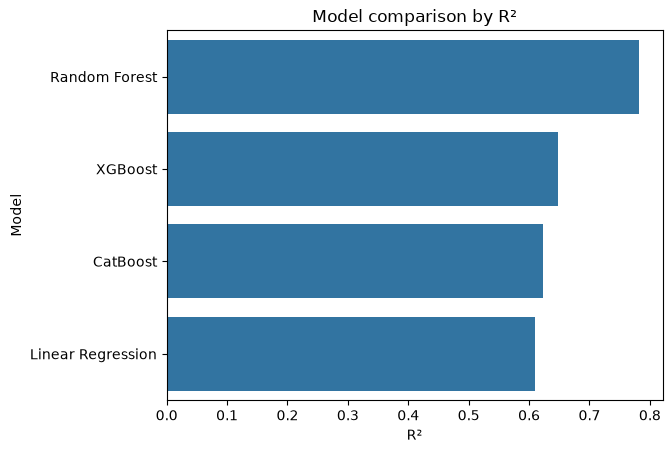

In [31]:
sns.barplot(
    data=model_results.sort_values("R²", ascending=False),
    x="R²",
    y="model"
)

plt.xlabel("R²")
plt.ylabel("Model")
plt.title("Model comparison by R²")
plt.show()

In [32]:
# Define the parameter grid for hyperparameter tuning of the Random Forest model
param_grid = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [10, 20],
    "model__min_samples_leaf": [1, 2]
}

In [33]:
# Set up the GridSearchCV for hyperparameter tuning of the Random Forest model
grid_search = GridSearchCV(
    estimator=model_random_forest,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=2
)

In [34]:
# Fit the GridSearchCV on the training data to find the best hyperparameters for the Random Forest model
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


KeyboardInterrupt: 

In [39]:
# Get the best model from the grid search
grid_search.best_params_


AttributeError: 'GridSearchCV' object has no attribute 'best_params_'

In [ ]:
# Get the best model from the grid search
grid_search.best_score_
best_mae_cv = -grid_search.best_score_
print(f"Best CV MAE: €{best_mae_cv:.2f}")



Best CV MAE: €136.76


In [40]:
# Get the best model from the grid search
best_model = grid_search.best_estimator_

y_pred_rf_tuned = best_model.predict(X_test)

AttributeError: 'GridSearchCV' object has no attribute 'best_estimator_'

In [ ]:
# Evaluate the tuned Random Forest model's performance using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score
mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)

print(f"Tuned Random Forest - MAE:  €{mae_rf_tuned:.2f}")
print(f"Tuned Random Forest - RMSE: €{rmse_rf_tuned:.2f}")
print(f"Tuned Random Forest - R²:   {r2_rf_tuned:.4f}")

Tuned Random Forest - MAE:  €136.79
Tuned Random Forest - RMSE: €245.76
Tuned Random Forest - R²:   0.6430


In [ ]:
print(f"Initial Random Forest - MAE:  €{mae_rf:.2f}")
print(f"Initial Random Forest - RMSE: €{rmse_rf:.2f}")
print(f"Initial Random Forest - R²:   {r2_rf:.4f}")

print()

print(f"Tuned Random Forest - MAE:  €{mae_rf_tuned:.2f}")
print(f"Tuned Random Forest - RMSE: €{rmse_rf_tuned:.2f}")
print(f"Tuned Random Forest - R²:   {r2_rf_tuned:.4f}")

Initial Random Forest - MAE:  €94.11
Initial Random Forest - RMSE: €192.02
Initial Random Forest - R²:   0.7821

Tuned Random Forest - MAE:  €136.79
Tuned Random Forest - RMSE: €245.76
Tuned Random Forest - R²:   0.6430


I tested different Random Forest configurations using cross-validation. The tuned model did not improve the initial Random Forest and performed significantly worse on the test set. Therefore, I kept the original Random Forest configuration as the final model.

## Feature Importance

In [ ]:
# Get the Random Forest model from the pipeline
rf_model = model_random_forest.named_steps["model"]

# Get the feature names after One-Hot Encoding
feature_names = model_random_forest.named_steps["preprocessor"].get_feature_names_out()

# Get the importance of each feature
importances = rf_model.feature_importances_

# Create a DataFrame with feature names and their importance
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(20)

,feature,importance
1710,numerical__stops,0.173946
1712,numerical__duration_minutes,0.154940
1711,numerical__days_left,0.052332
1242,categorical__source_airport_FCO,0.050189
1006,categorical__airline_Scandinavian Airlines + B...,0.026853
323,categorical__airline_British Airways + Scandin...,0.020855
1660,categorical__destination_airport_SVO,0.016193
1033,categorical__airline_Scandinavian Airlines + T...,0.013385
1496,categorical__destination_airport_DME,0.012898
1102,categorical__airline_Tap Air Portugal + Scandi...,0.008667


In [ ]:
# Create a new column in the feature_importance DataFrame to store the original feature names by removing the prefixes and suffixes from the transformed feature names  
feature_importance["original_feature"] = (
    feature_importance["feature"]
    .str.replace("categorical__", "", regex=False)
    .str.replace("numerical__", "", regex=False)
    .str.rsplit("_", n=1)
    .str[0]
)

NameError: name 'feature_importance' is not defined

In [ ]:
# Create a function to get the original feature name from the transformed feature name
def get_original_feature(feature):
    feature = feature.replace("categorical__", "")
    feature = feature.replace("numerical__", "")

    # Numerical features
    if feature in numerical_features:
        return feature

    # Categorical features
    for col in categorical_features:
        if feature.startswith(col + "_"):
            return col

    return feature

In [ ]:
# Apply the function to get the original feature names
feature_importance["original_feature"] = feature_importance["feature"].apply(get_original_feature)

# Group the feature importance by the original feature names and sum their importance
original_importance = (
    feature_importance
    .groupby("original_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
)
original_importance

original_feature
airline                  0.315496
stops                    0.173946
duration_minutes         0.154940
source_airport           0.139196
destination_airport      0.116438
days_left                0.052332
departure_day_of_week    0.026036
departure_daypart        0.021617
Name: importance, dtype: float64

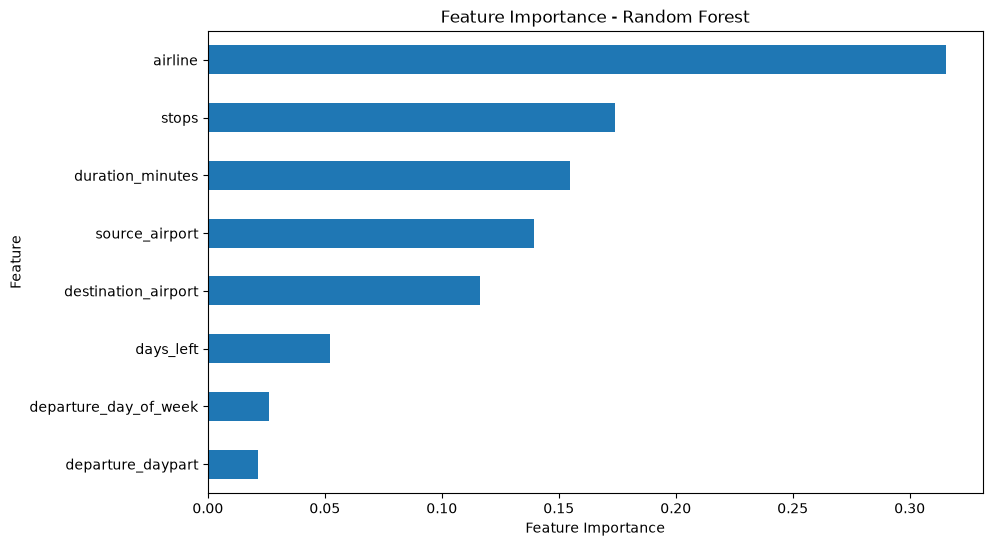

In [ ]:
plt.figure(figsize=(10, 6))

original_importance.sort_values().plot(kind="barh")

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")

plt.show()

### Model Interpretation

Feature importance was used to interpret the final Random Forest model. Since categorical variables were transformed using One-Hot Encoding, the importance of individual encoded features was aggregated back to the original variables.

The results show that airline is the most influential feature, followed by stops, flight duration, source airport, and destination airport. Days left has a smaller but still meaningful contribution, while departure day of week and departure daypart have comparatively lower importance.

SHAP was explored as an additional model interpretation technique. However, due to the computational cost associated with explaining the large number of encoded features in the Random Forest, the analysis was not used as a primary result.

## 5.9 Final Model Evaluation

Random Forest achieved the best performance among the models evaluated in this project.

Hyperparameter tuning was performed to investigate whether the baseline configuration could be improved. Since the tuned configuration performed worse, the original Random Forest was retained as the final model.

The final model is evaluated on the test set using MAE, RMSE, and R² to assess its predictive performance on previously unseen data.

In [43]:
# Final evaluation of the selected Random Forest model

print(f"Final Random Forest - MAE:  €{mae_rf:.2f}")
print(f"Final Random Forest - RMSE: €{rmse_rf:.2f}")
print(f"Final Random Forest - R²:   {r2_rf:.4f}")

Final Random Forest - MAE:  €94.11
Final Random Forest - RMSE: €192.02
Final Random Forest - R²:   0.7821


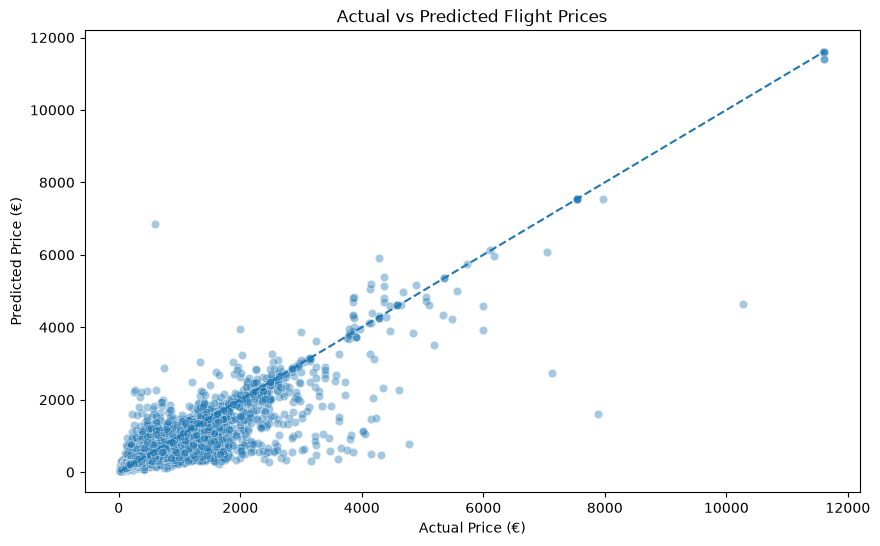

In [44]:
#  
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_rf,
    alpha=0.4
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price (€)")
plt.ylabel("Predicted Price (€)")
plt.title("Actual vs Predicted Flight Prices")

plt.show()

### Final Model Assessment

The Actual vs Predicted plot shows that the Random Forest model captures the general relationship between actual and predicted flight prices.

Most observations are concentrated around the diagonal, indicating reasonable predictive performance for a large portion of the dataset. However, the model shows greater dispersion for higher-priced flights and tends to underestimate some extreme prices.

This is consistent with the difference between the MAE and RMSE, as large prediction errors have a stronger effect on RMSE.

Overall, the Random Forest provides a strong baseline for flight price prediction, while acknowledging that extreme and unusually expensive flights remain more difficult to predict accurately.


## 6. Model Export & Application

The final Random Forest model achieved the best predictive performance among the evaluated models.

In this section, the complete preprocessing and modeling pipeline will be saved so that it can be reused to make predictions on new flight observations without retraining the model.

This will also allow the model to be integrated into a future application for estimating flight prices.

In [46]:
# Save the complete preprocessing + Random Forest pipeline
joblib.dump(
    model_random_forest,
    "random_forest_flight_price_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [47]:
# Load the saved model
loaded_model = joblib.load(
    "random_forest_flight_price_model.pkl"
)

print("Model loaded successfully.")

Model loaded successfully.


### Model Persistence Test

The saved pipeline is loaded again to verify that it produces the same predictions as the original trained model.

This confirms that the exported model can be reused independently from the training session.

In [48]:
# Compare predictions from the original and loaded models

original_predictions = model_random_forest.predict(X_test)
loaded_predictions = loaded_model.predict(X_test)

# Check whether predictions are the same
predictions_match = np.allclose(
    original_predictions,
    loaded_predictions
)

print("Predictions match:", predictions_match)

Predictions match: True
